In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('raw_data/Churn_Modelling.csv')
print('Shape:',df.shape)
print('Columns:',df.columns.tolist())
df.head()

Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
print("Missing Values:\n", df.isnull().sum())
print("\nChurn Distribution:")
print(df['Exited'].value_counts())
print("\nGeography Distribution:")
print(df['Geography'].value_counts())
print("\nGender Distribution:")
print(df['Gender'].value_counts())
print("\nStatistical Summary:")
df.describe()

Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Geography Distribution:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender Distribution:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Statistical Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


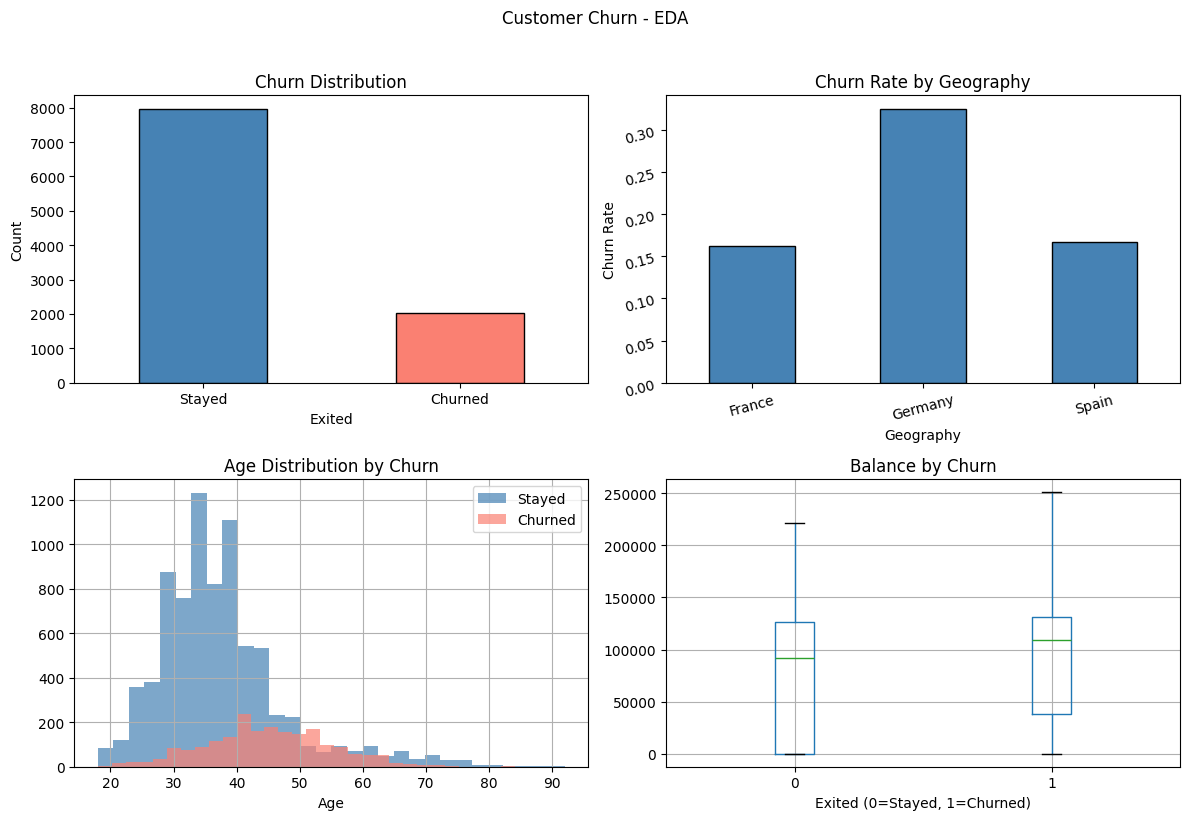

In [6]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Churn Distribution
df['Exited'].value_counts().plot(kind='bar', ax=axes[0,0],
                                  color=['steelblue','salmon'], edgecolor='black')
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xticklabels(['Stayed', 'Churned'], rotation=0)
axes[0,0].set_ylabel('Count')

# Churn by Geography
df.groupby('Geography')['Exited'].mean().plot(kind='bar', ax=axes[0,1],
                                               color='steelblue', edgecolor='black')
axes[0,1].set_title('Churn Rate by Geography')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].tick_params(rotation=15)

# Age Distribution by Churn
df[df['Exited']==0]['Age'].hist(bins=30, ax=axes[1,0], alpha=0.7, 
                                 label='Stayed', color='steelblue')
df[df['Exited']==1]['Age'].hist(bins=30, ax=axes[1,0], alpha=0.7, 
                                 label='Churned', color='salmon')
axes[1,0].set_title('Age Distribution by Churn')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

# Balance by Churn
df.boxplot(column='Balance', by='Exited', ax=axes[1,1])
axes[1,1].set_title('Balance by Churn')
axes[1,1].set_xlabel('Exited (0=Stayed, 1=Churned)')

plt.suptitle('Customer Churn - EDA', y=1.02)
plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150)
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Drop useless columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])

# Features and target
X = df.drop(columns=['Exited'])
y = df['Exited']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                      test_size=0.2, 
                                                      random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

Model trained!
Train: 8000 samples, Test: 2000 samples


Accuracy: 86.40%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



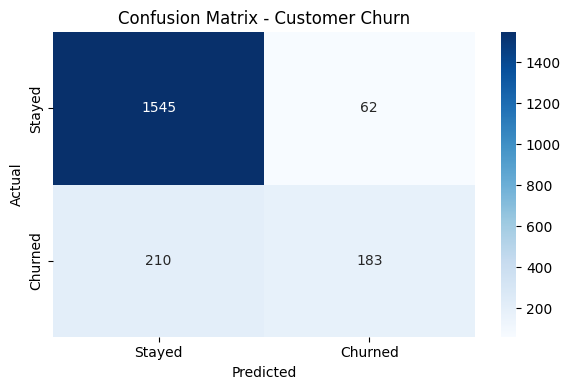

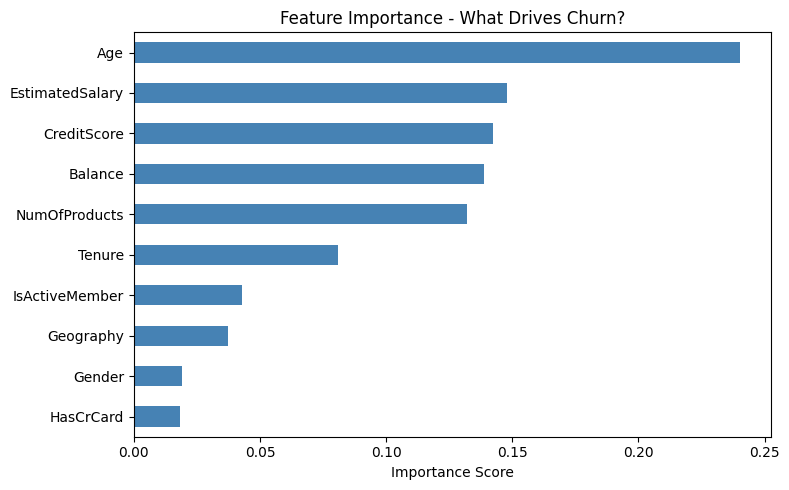

In [8]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix - Customer Churn')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Feature Importance
feature_importance = pd.Series(model.feature_importances_, 
                                index=df.drop(columns=['Exited']).columns)
feature_importance.sort_values().plot(kind='barh', figsize=(8,5), 
                                       color='steelblue')
plt.title('Feature Importance - What Drives Churn?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()